Bloque 1 - Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Bloque 2 - Imporatmos la libreria tensorflow

In [ ]:
import tensorflow as tf

BLoque 3 - Descarga de datos

In [ ]:
import kagglehub # Importa la librería kagglehub para interactuar con Kaggle y descargar datasets.

path = kagglehub.dataset_download("muhammedjunayed/wavelet-transformed-eeg-data-for-alcohol-detection")

print("Path to dataset files:", path) # Imprime la ruta donde se han descargado los archivos del dataset.

100%|██████████| 21.3M/21.3M [00:01<00:00, 12.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammedjunayed/wavelet-transformed-eeg-data-for-alcohol-detection/versions/1


Bloque 4 - Exploracion de archivos

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


path = Path(path)
img_as_jpg = list(path.rglob(r"*/*.jpg"))

# Counts the number of each categories in the dataset
file_count = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],img_as_jpg))
Alc = file_count.count('Alc')
Con = file_count.count('Con')

In [ ]:
Alc

468

In [ ]:
Con

456

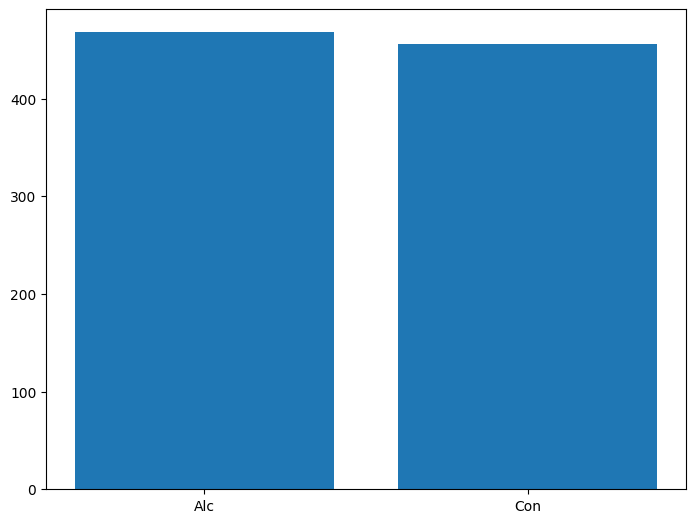

In [ ]:
#VISUALIZACION DE DATA POR CLASES ALCOHOL O CONTROL
fig = plt.figure()
ax = fig.add_axes([1,1,1,1])
labels = ['Alc','Con']
count_train = [Alc, Con] # count_train should contain the count of each label
ax.bar(labels, count_train)
plt.show()

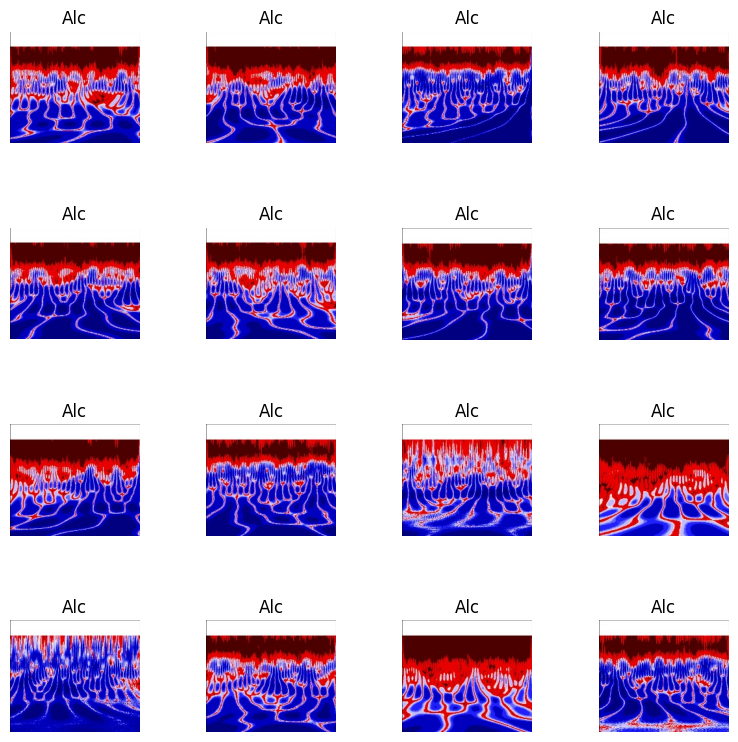

In [ ]:
# Crear el DataFrame 'train' necesario con las rutas de las imágenes y sus etiquetas
train = pd.DataFrame({
    "image": [str(x) for x in img_as_jpg],
    "type": file_count
})

#09
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
fig.tight_layout()
counter = 0
for ax in axes.reshape(-1):
    if counter < len(train):
        ax.imshow(plt.imread(train["image"][counter]))
        ax.set_title(train["type"][counter])
        plt.rcParams["axes.grid"] = False
        ax.axis('off') # Ocultar ejes para mejor visualización
    counter = counter+1
plt.show()

BLOQUE 5 - IMPLEMENTACION DEL MODELO MOBILENETV2

In [ ]:
#MODELO TRANSFER LEARNING - MOBILENETV2
#BLOQUE 01
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# Clase utilitaria para acceder a claves de diccionario como atributos
class AttrDict(dict):
    __setattr__ = dict.__setitem__
    __getattr__ = dict.__getitem__

# Función de visualización
def plot_grid_ds(ds, model=None, size=(3, 3), figsize=(10, 10)):
    from copy import copy
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import ImageGrid

    n = size[0] * size[1]
    ds_ = copy(ds)

    fig = plt.figure(figsize=figsize)
    grid = ImageGrid(
        fig,
        111,
        nrows_ncols=size,
        axes_pad=0.3,
    )
    for X_batch, y_batch in ds_.unbatch().shuffle(n).batch(n).take(1):
        y_hat_batch = model.predict(X_batch).argmax(axis=-1) if model else y_batch
        for X, y, y_hat, ax in zip(X_batch, y_batch, y_hat_batch, grid):
            title = (
                f"{ds.class_names[y]} (true) - {ds.class_names[y_hat]} (pred)"
                if model
                else f"{ds.class_names[y]}"
            )
            ax.set_title(title)
            ax.axes.xaxis.set_visible(False)
            ax.axes.yaxis.set_visible(False)
            ax.imshow(X / 255, cmap="gray")
    return grid

# Métrica personalizada
class BalancedSparseCategoricalAccuracy(tf.keras.metrics.SparseCategoricalAccuracy):
    def __init__(self, name="balanced_sparse_categorical_accuracy", dtype=None):
        super().__init__(name, dtype=dtype)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_flat = y_true
        if y_true.shape.ndims == y_pred.shape.ndims:
            y_flat = tf.squeeze(y_flat, axis=[-1])
        y_true_int = tf.cast(y_flat, tf.int32)

        cls_counts = tf.math.bincount(y_true_int)
        cls_counts = tf.math.reciprocal_no_nan(tf.cast(cls_counts, self.dtype))
        weight = tf.gather(cls_counts, y_true_int)
        return super().update_state(y_true, y_pred, sample_weight=weight)

# --- IMPLEMENTACIÓN TRANSFER LEARNING (MobileNetV2) ---

def build_mobilenetv2_model(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)

    # 1. Preprocesamiento específico para MobileNetV2 (escala de [0, 255] a [-1, 1])
    x = layers.Rescaling(1./127.5, offset=-1)(inputs)

    # 2. Base Model pre-entrenado en ImageNet
    base_model = applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False, # No incluir la capa de clasificación final de ImageNet
        weights='imagenet'
    )

    # 3. Fine-Tuning: Descongelamos el modelo base para ajustar los pesos a los EEG
    base_model.trainable = True

    x = base_model(x)

    # 4. Cabezal de Clasificación (Top)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x) # Dropout alto para regularización dada la data pequeña
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes)(x) # Salida sin activación (logits)

    model = models.Model(inputs, outputs, name="MobileNetV2_TransferLearning")
    return model

In [ ]:
# CONFIGURACIÓN DE DATASET CON DATA AUGMENTATION (CRUCIAL PARA >90%)
import tensorflow as tf
from tensorflow.keras import layers

hparams = AttrDict(
    image_size=(224, 224, 3),
    n_classes=2,
    batch_size=32, # Reducimos batch size para mejorar la generalización
)

# 1. Definir Tubería de Aumentación de Datos
# Esto genera nuevas variaciones de las imágenes en tiempo real
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2), # Rotación hasta 20%
    layers.RandomZoom(0.2),     # Zoom hasta 20%
    layers.RandomContrast(0.2), # Cambio de contraste
    layers.RandomBrightness(0.2),
], name="data_augmentation")

# 2. Cargar Dataset Original
ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/Papper_Titulo /EEG",
    image_size=hparams.image_size[:-1],
    batch_size=hparams.batch_size,
    shuffle=True,
    seed=42
)

class_names = ds.class_names

# 3. Split Train/Validation (80/20)
num_batches = ds.cardinality().numpy()
train_size = int(0.8 * num_batches)

train_ds = ds.take(train_size)
validation_ds = ds.skip(train_size)

# 4. Aplicar Aumentación SOLO al conjunto de Entrenamiento
# Usamos num_parallel_calls para que sea rápido (no bloquee el entrenamiento)
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# 5. Optimización de Carga (Cache & Prefetch)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Preservar nombres de clases
train_ds.class_names = class_names
validation_ds.class_names = class_names

print(f"\nData Augmentation Configurada.")
print(f"Batches de Entrenamiento (Aumentados): {train_size}")
print(f"Batches de Validación (Originales): {num_batches - train_size}")

Found 924 files belonging to 2 classes.

Data Augmentation Configurada.
Batches de Entrenamiento (Aumentados): 23
Batches de Validación (Originales): 6


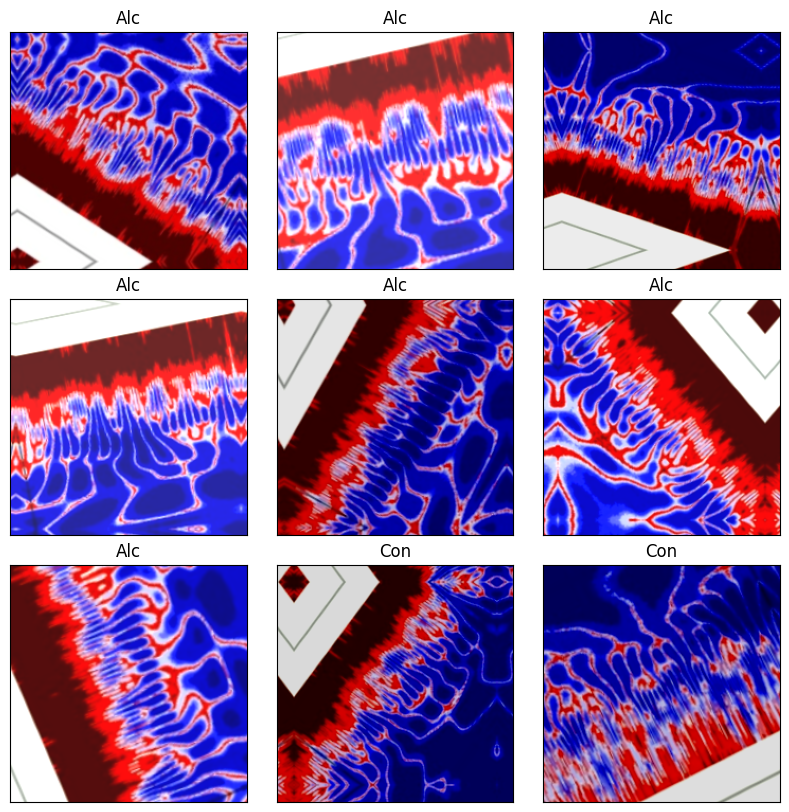

In [ ]:
_ = plot_grid_ds(train_ds)


BLOQUE 5: RESULTADOS DEL MODELO MOBILE VIT

---



---



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

[ETAPA 1] Base Model 'mobilenetv2_1.00_224' CONGELADO para entrenamiento inicial.

--- INICIANDO ETAPA 1: Feature Extraction (Solo Head) ---
Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4904 - balanced_sparse_categorical_accuracy: 0.5002 - loss: 1.2163
Epoch 1: val_accuracy improved from -inf to 0.60106, saving model to /content/drive/MyDrive/Papper_Titulo /best_mobilenetv2_eeg_finetuned.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 677ms/step - accuracy: 0.4899 - balanced_sparse_categorical_accuracy: 0.4998 - loss: 1.2120 - val_accuracy: 0.6011 - val_balanced_sparse_categorical_accuracy: 0.6131 - val_loss: 0.6468
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5749 - balanced_sparse_categorical_accuracy: 0.5671 - loss: 0.7803
Epoch 2: val_accuracy improved from 0.60106 to 0.61170, saving model to /content/drive/MyDrive/Papper_Titulo /best_mobilenetv2_eeg_finetuned.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/ste

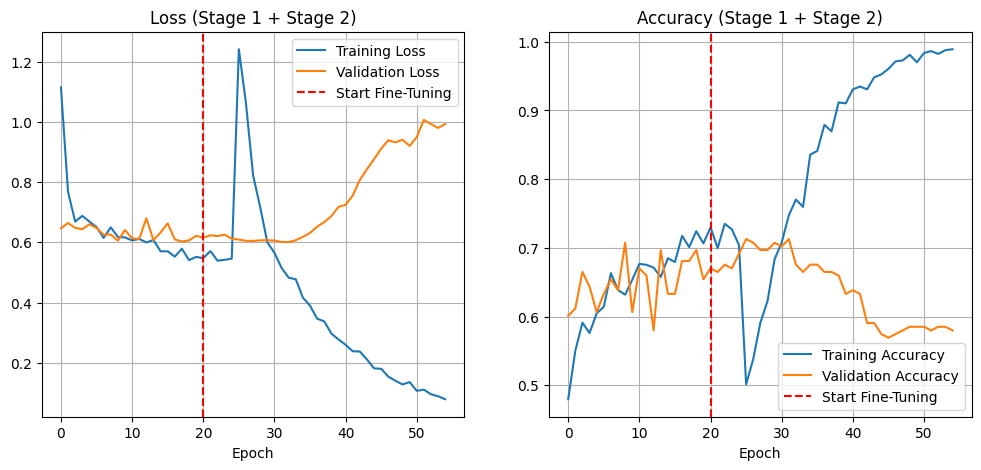


Cargando el MEJOR modelo optimizado: /content/drive/MyDrive/Papper_Titulo /best_mobilenetv2_eeg_finetuned.keras
Generando reporte de métricas...
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 245ms/step


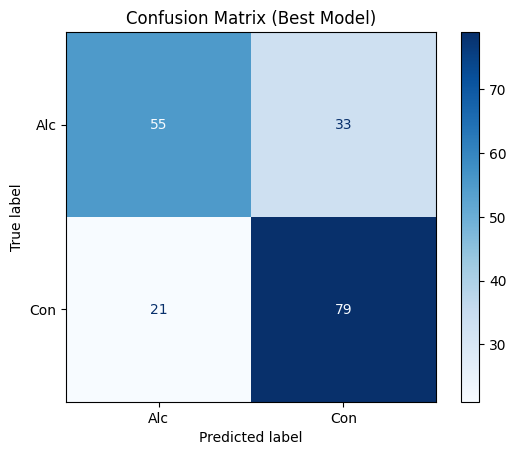


FINAL VALIDATION ACCURACY: 71.28%
MACRO F1-SCORE: 0.7080
Class-wise F1: [0.67073171 0.74528302]



In [ ]:
# ESTRATEGIA AVANZADA: 2-STAGE FINE-TUNING + DATA AUGMENTATION
import time
import tensorflow as tf
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

# Verificar estrategia de distribución
if 'strategy' not in globals():
    strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    input_shape = hparams['image_size']
    n_classes = hparams['n_classes']

    # 1. Construir el modelo base (MobileNetV2)
    model = build_mobilenetv2_model(input_shape, n_classes)

    # Identificar y congelar el modelo base para la Etapa 1
    base_model_layer = None
    for layer in model.layers:
        # CORRECCIÓN: Buscamos por nombre ya que MobileNetV2 es una función
        if "mobilenet" in layer.name.lower():
            base_model_layer = layer
            break

    if base_model_layer:
        base_model_layer.trainable = False
        print(f"\n[ETAPA 1] Base Model '{base_model_layer.name}' CONGELADO para entrenamiento inicial.")

    # Compilar para Etapa 1
    model.compile(
        optimizer='adam', # LR por defecto 0.001
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy", BalancedSparseCategoricalAccuracy()]
    )

# Callback para guardar el mejor modelo
checkpoint_path = "/content/drive/MyDrive/Papper_Titulo /best_mobilenetv2_eeg_finetuned.keras"
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# Historial acumulativo para graficar ambas etapas juntas
class TrainingHistory(tf.keras.callbacks.Callback):
    def __init__(self):
        self.losses = []
        self.val_losses = []
        self.accuracies = []
        self.val_accuracies = []
    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.accuracies.append(logs.get('accuracy'))
        self.val_accuracies.append(logs.get('val_accuracy'))

history_callback = TrainingHistory()

start = time.time()

# --- ETAPA 1: ENTRENAMIENTO DEL CLASIFICADOR (20 Epochs) ---
print("\n--- INICIANDO ETAPA 1: Feature Extraction (Solo Head) ---")
# Usamos train_ds que YA TIENE data augmentation aplicado en el bloque anterior
model.fit(train_ds, epochs=25, validation_data=validation_ds, callbacks=[history_callback, checkpoint_cb])

# --- ETAPA 2: FINE-TUNING COMPLETO (30 Epochs más) ---
print("\n--- INICIANDO ETAPA 2: Fine-Tuning (Full Unfreeze & Low LR) ---")

with strategy.scope():
    # Descongelar el modelo base
    if base_model_layer:
        base_model_layer.trainable = True
        print(f"[ETAPA 2] Base Model '{base_model_layer.name}' DESCONGELADO.")
    else:
        # Fallback si no se encontró la capa específica (ej. modelo funcional plano)
        model.trainable = True

    # Re-compilar con Learning Rate MUY BAJO (1e-5) para ajuste fino
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy", BalancedSparseCategoricalAccuracy()]
    )

# Entrenamos por 30 épocas más (total 50)
model.fit(train_ds, epochs=30, validation_data=validation_ds, callbacks=[history_callback, checkpoint_cb])

end = time.time()
print(f"Tiempo total: {end - start:.2f} s")

# --- Visualización de Resultados Combinados ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_callback.losses, label='Training Loss')
plt.plot(history_callback.val_losses, label='Validation Loss')
plt.axvline(x=20, color='r', linestyle='--', label='Start Fine-Tuning')
plt.title('Loss (Stage 1 + Stage 2)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_callback.accuracies, label='Training Accuracy')
plt.plot(history_callback.val_accuracies, label='Validation Accuracy')
plt.axvline(x=20, color='r', linestyle='--', label='Start Fine-Tuning')
plt.title('Accuracy (Stage 1 + Stage 2)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# --- Evaluación Final del Mejor Modelo ---
if os.path.exists(checkpoint_path):
    print(f"\nCargando el MEJOR modelo optimizado: {checkpoint_path}")
    model.load_weights(checkpoint_path)

# Métricas
X_val, y_true = [], []
print("Generando reporte de métricas...")
for images, labels in validation_ds:
    X_val.extend(images.numpy())
    y_true.extend(labels.numpy())
X_val = np.array(X_val)
y_true = np.array(y_true)

y_pred = model.predict(X_val).argmax(axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=validation_ds.class_names)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix (Best Model)')
plt.show()

# Reporte
accuracy = np.mean(y_true == y_pred)
class_wise_precision = precision_score(y_true, y_pred, average=None)
class_wise_recall = recall_score(y_true, y_pred, average=None)
class_wise_f1 = f1_score(y_true, y_pred, average=None)
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f"\n{'='*30}")
print(f"FINAL VALIDATION ACCURACY: {accuracy * 100:.2f}%")
print(f"MACRO F1-SCORE: {macro_f1:.4f}")
print(f"Class-wise F1: {class_wise_f1}")
print(f"{'='*30}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step


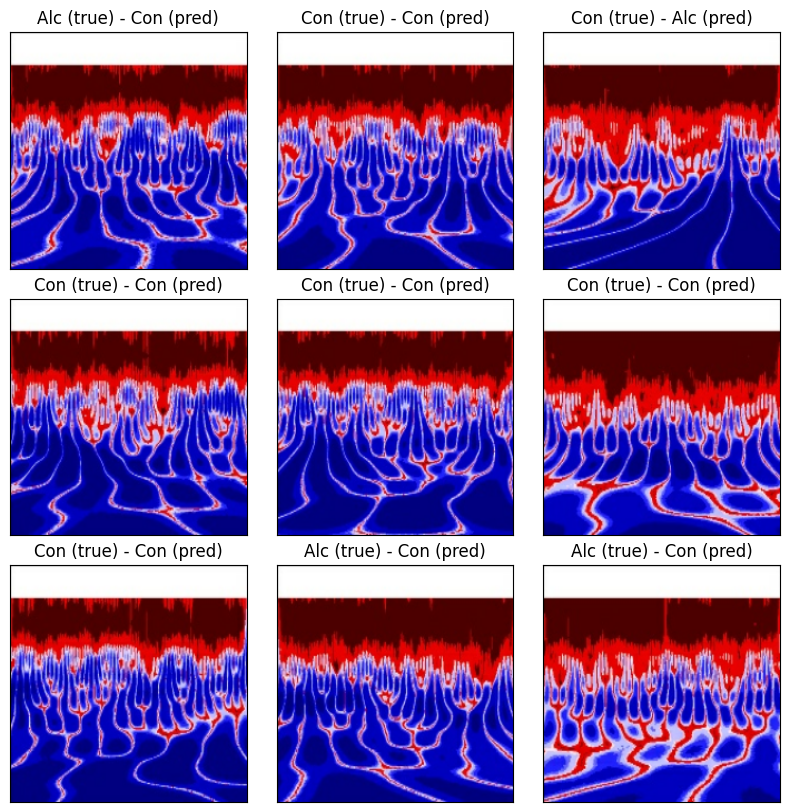

In [ ]:
_ = plot_grid_ds(validation_ds,  model=model)

In [ ]:
print("\nMacro F1-score:", macro_f1)



Macro F1-score: 0.7080073630924988


In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score

# Calculate missing macro metrics
macro_precision = precision_score(y_true, y_pred, average='macro')
macro_recall = recall_score(y_true, y_pred, average='macro')

# === Datos del modelo ===
MODEL_NAME = "MobileNetV2" # Actualizado para el nuevo experimento
EPOCHS = 25
BATCH_SIZE = hparams.batch_size

# Obtener LR y optimizador desde el propio modelo
try:
    learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
    optimizer_name = type(model.optimizer).__name__
except:
    learning_rate = 0.0001
    optimizer_name = "Adam"

# Crear DataFrame con una fila de resultados
df_resultados = pd.DataFrame([{
    "Model": MODEL_NAME,
    "Accuracy": round(accuracy, 4),
    "Precision": round(macro_precision, 4),
    "Recall": round(macro_recall, 4),
    "F1-Score": round(macro_f1, 4),
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,

}])

# Mostrar tabla bonita en el notebook
df_resultados

,Model,Accuracy,Precision,Recall,F1-Score,batch_size,epochs
0,MobileNetV2,0.7128,0.7145,0.7075,0.708,32,25


In [ ]:
# Parche para corregir el conflicto de 'AttrDict'
try:
    if 'AttrDict' in globals():
        def getattr_patch(self, key):
            try:
                return self[key]
            except KeyError:
                raise AttributeError(f"'AttrDict' object has no attribute '{key}'")
        AttrDict.__getattr__ = getattr_patch
except Exception:
    pass

# Guardar el modelo con nombre actualizado
save_path = '/content/drive/MyDrive/Papper_Titulo /07_MobileNetV2_EEG.keras'

model.save(save_path)
print(f"Modelo optimizado guardado exitosamente en: {save_path}")

Modelo optimizado guardado exitosamente en: /content/drive/MyDrive/Papper_Titulo /07_MobileNetV2_Augmented_EEG.keras


In [ ]:
# Tabla por clase
df_por_clase = pd.DataFrame({
    "Class": validation_ds.class_names,
    "Precision": class_wise_precision,
    "Recall": class_wise_recall,
    "F1-Score": class_wise_f1,
})

df_por_clase

,Class,Precision,Recall,F1-Score
0,Alc,0.723684,0.625,0.670732
1,Con,0.705357,0.790,0.745283
